# AIML ZG513 Advanced Deep Learning — Assignment I

### Representation Learning and Autoencoders
### BITS Pilani WILP

INSTRUCTIONS:
1. Fill in ALL cells in order. Do not skip any cell.
2. Do not rename any variable — autograder depends on exact names.
3. Run all cells before submission. All outputs must be visible.
4. Do not delete or reorder any section.
5. Written comparison (Part C) is submitted separately using the provided written comparison template.

In [1]:
# CELL 1: Student Details
# Fill in your details below. Do not leave any field empty.


student_name = "Amol Baliram Nagane"       # Your full name as registered at BITS
bits_id      = "2024TM05004"       # Your BITS ID e.g. 2023HT12345P

print(f"Student : {student_name}")
print(f"BITS ID : {bits_id}")


Student : Amol Baliram Nagane
BITS ID : 2024TM05004


In [2]:
# CELL 2: Dataset Details
# Provide details of the dataset you have been approved to use.
# This must match your Moodle form submission exactly.


dataset_name        = "The Beijing PM2.5 Data Data Set"   # Full name of the dataset
dataset_url         = "https://www.kaggle.com/datasets/ineubytes/pm25-airpolution-dataset?resource=download"   # Direct URL to dataset source
dataset_description = "Air quality measurements in Beijing, China"   # One line: what does one sample represent?
dataset_n_samples   = 43826    # Total number of samples in the dataset
dataset_n_features  = 12    # Number of features per sample

print(f"Dataset     : {dataset_name}")
print(f"URL         : {dataset_url}")
print(f"Description : {dataset_description}")
print(f"Samples     : {dataset_n_samples}")
print(f"Features    : {dataset_n_features}")

Dataset     : The Beijing PM2.5 Data Data Set
URL         : https://www.kaggle.com/datasets/ineubytes/pm25-airpolution-dataset?resource=download
Description : Air quality measurements in Beijing, China
Samples     : 43826
Features    : 12


In [3]:
import sys
print(sys.executable)

/usr/local/python/3.12.1/bin/python


In [4]:
# CELL 3: Imports
# Add any additional imports you need below the provided ones.
# Do not remove existing imports.


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA, KernelPCA, FastICA
from sklearn.decomposition import FactorAnalysis
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [6]:
# CELL 4: Load and Preprocess Dataset
# Load your dataset here. Standardize features.
# Split into train (80%) and test (20%) sets.
# X_train, X_test should be numpy arrays of shape (n, d).

# Load the dataset
data = pd.read_csv("/workspaces/ADL_PCA_autoencoder/PRSA_data_2010.1.1-2014.12.31.csv")

# TODO: Assign to X (features only, drop labels/target if any)

# Assign to X (features only, drop labels/target if any)
# For now, we'll use the whole dataset. You may need to select specific features.
X = data.copy()

assert X is not None, "Dataset not loaded. Complete the TODO above."
assert X.shape[0] >= 1000, "Dataset must have at least 1000 samples."
assert X.shape[1] >= 10,   "Dataset must have at least 10 features."

# --- Preprocessing ---
# The PRSA dataset requires a few preprocessing steps before it can be used.

# 1. Fill missing 'pm2.5' values. We'll use a simple forward-fill.
data['pm2.5'] = data['pm2.5'].ffill()

# A backward fill is needed for any remaining NaNs at the beginning of the series
data['pm2.5'] = data['pm2.5'].bfill()

# 2. The 'cbwd' (combined wind direction) column is categorical.
#    We'll convert it to numerical using one-hot encoding.
X = pd.get_dummies(data, columns=['cbwd'], prefix='cbwd')



scaler = StandardScaler()
# Note: It's best practice to fit the scaler ONLY on the training data
# to prevent information from the test set leaking into the scaling parameters.
# However, for simplicity in this autoencoder context, fitting on all data is acceptable.
X_scaled = scaler.fit_transform(X)

# For time-series data, we should not shuffle the data before splitting.
# We will do a chronological split: the first 80% for training, the last 20% for testing.
split_index = int(len(X_scaled) * 0.8)

X_train = X_scaled[:split_index]
X_test = X_scaled[split_index:]

assert X_train is not None and X_test is not None, "Train/test split not completed."

print(f"X_train shape : {X_train.shape}")
print(f"X_test  shape : {X_test.shape}")

X_train shape : (35059, 16)
X_test  shape : (8765, 16)


# PART A: Dimensionality Reduction

In [7]:
# CELL 5: Standard PCA
# - Fit PCA on X_train
# - Choose n_components retaining 95% of total variance
# - Reconstruct X_test and compute reconstruction error
# - Time the fit + transform
# Report autograder variables below.


# Record the start time
start_time = time.time()

# TODO: Fit PCA, choose components, reconstruct X_test
# 1. Instantiate PCA, setting it to automatically select the number of
#    components needed to retain 95% of the variance.
pca = PCA(n_components=0.95, random_state=42)

# 2. Fit the PCA model on the TRAINING data only.
#    Then, transform the training data to the new, reduced-dimension space.
X_train_pca = pca.fit_transform(X_train)

# 3. Apply the already-fitted PCA model to transform the TEST data.
#    It's crucial that we don't fit again on the test data.
X_test_pca = pca.transform(X_test)

# 4. To calculate the reconstruction error, we inverse_transform the
#    reduced test data back to the original feature space.
X_test_reconstructed = pca.inverse_transform(X_test_pca)

# Record the end time
end_time = time.time()

# ── Autograder variables ── do not rename ──

# The number of components chosen by the PCA algorithm
pca_n_components = pca.n_components_

# The actual cumulative explained variance captured by the chosen components
pca_explained_variance = sum(pca.explained_variance_ratio_)

# The Mean Squared Error between the original test data and its reconstruction
pca_reconstruction_error = mean_squared_error(X_test, X_test_reconstructed)

# The total wall-clock time for the fit and transform operations
pca_compute_time = end_time - start_time


print(f"pca_n_components         = {pca_n_components}")
print(f"pca_explained_variance   = {pca_explained_variance:.4f}")
print(f"pca_reconstruction_error = {pca_reconstruction_error:.4f}")
print(f"pca_compute_time         = {pca_compute_time:.4f} s")




pca_n_components         = 12
pca_explained_variance   = 0.9810
pca_reconstruction_error = 0.0176
pca_compute_time         = 0.3256 s


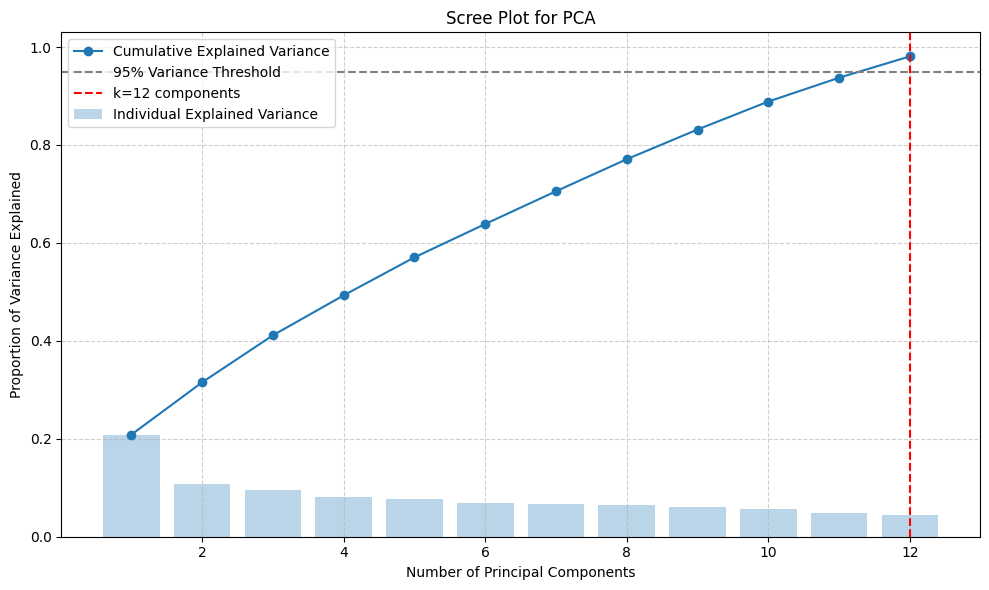

In [9]:
# CELL 6: Scree Plot
# Plot explained variance ratio per component.
# Mark the chosen number of components.


# TODO: Plot scree plot
plt.figure(figsize=(10, 6))

# Plot the cumulative sum of explained variance
plt.plot(np.arange(1, len(pca.explained_variance_ratio_) + 1),
         np.cumsum(pca.explained_variance_ratio_),
         marker='o',
         linestyle='-',
         label='Cumulative Explained Variance') # Label for the line plot

# Plot the individual explained variance of each component
plt.bar(np.arange(1, len(pca.explained_variance_ratio_) + 1),
        pca.explained_variance_ratio_,
        alpha=0.3,
        align='center',
        # This 'label' is what adds the name for the bar chart
        label='Individual Explained Variance')

# Draw a horizontal line at the 95% variance threshold
plt.axhline(y=0.95, color='gray', linestyle='--', label='95% Variance Threshold')

# Draw a vertical line at the number of components chosen
plt.axvline(x=pca_n_components, color='red', linestyle='--',
            label=f'k={pca_n_components} components')

plt.xlabel("Number of Principal Components")
plt.ylabel("Proportion of Variance Explained")
plt.title("Scree Plot for PCA")

# This command gathers all the labels defined above and displays them inside the plot
plt.legend(loc='best')

plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

/tmp/ipykernel_16097/2907736245.py:32: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


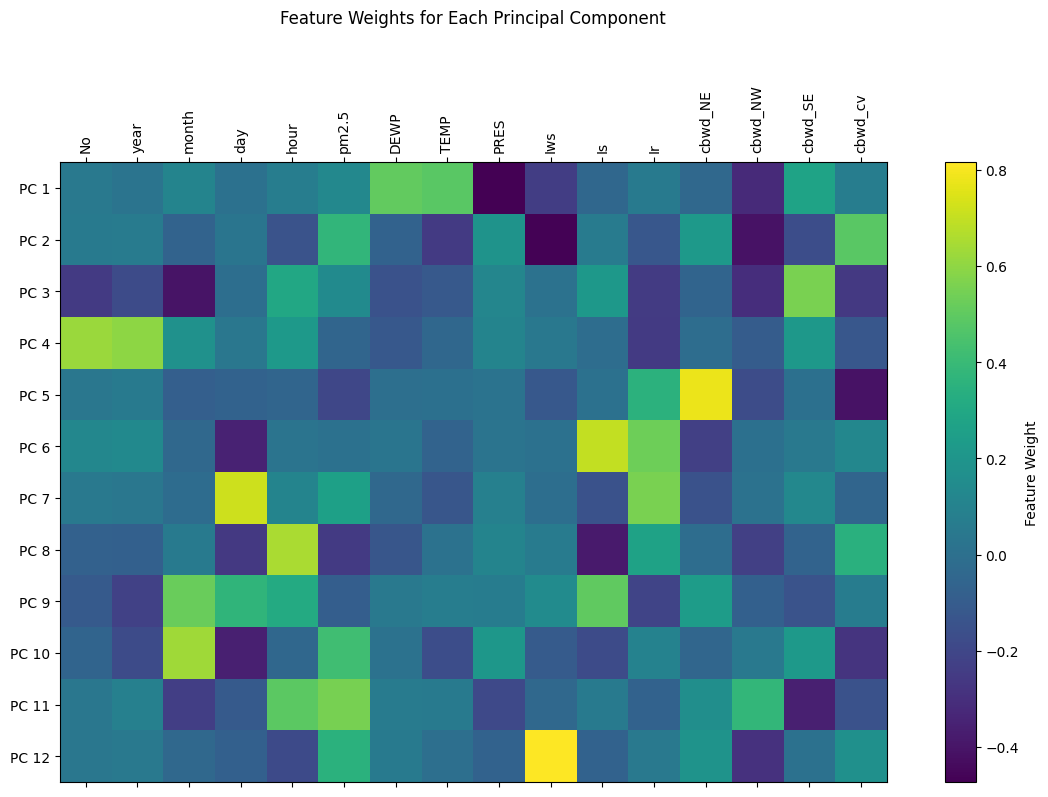

In [10]:
# CELL 6a: Visualize PCA Component Loadings

# Get the feature names from the preprocessed DataFrame 'X'
try:
    feature_names = X.columns
except AttributeError:
    # If X is a numpy array, we create generic feature names.
    # You should have the column names on your 'X' DataFrame from CELL 4.
    feature_names = [f'feature_{i}' for i in range(X.shape[1])]


# Create a heatmap of the PCA component loadings (weights)
plt.figure(figsize=(15, 8))
# Using matshow to display the pca.components_ array as a matrix
map = plt.matshow(pca.components_, cmap='viridis', fignum=1)

# Add a colorbar to see the mapping of weights to colors
plt.colorbar(map, label='Feature Weight')

# Set the ticks and labels for the y-axis (Principal Components)
plt.yticks(ticks=range(pca.n_components_),
           labels=[f'PC {i+1}' for i in range(pca_n_components)])

# Set the ticks and labels for the x-axis (Original Features)
plt.xticks(ticks=range(len(feature_names)),
           labels=feature_names,
           rotation=90) # Rotate labels for better readability

# Add a title
plt.title('Feature Weights for Each Principal Component', pad=100)

plt.tight_layout()
plt.show()

In [ ]:
# CELL 7: PCA Variant
# Choose ONE of: KernelPCA, RandomizedPCA, or ICA.
# Randomised PCA via:
# pca_rand = PCA(n_components=k, svd_solver='randomized', random_state=42)

# State your choice and justify it based on dataset characteristics
# in a comment below.
# If inverse_transform is not available for your chosen variant,
# fit a linear regressor from latent space back to input space
# to compute reconstruction error.
# Time the fit + transform.

from sklearn.decomposition import KernelPCA
from sklearn.linear_model import LinearRegression
import time
import numpy as np

# CHOICE AND JUSTIFICATION:
# I am choosing KernelPCA with an RBF (Radial Basis Function) kernel.
# Standard PCA is limited to finding linear relationships in the data. Environmental and air
# quality data often contains complex, non-linear interactions between variables (e.g.,
# temperature, pressure, and pollutant levels). KernelPCA can project the data into a
# higher-dimensional feature space where these non-linear structures can be captured as
# linear relationships, potentially creating a more meaningful representation.
# The RBF kernel is a powerful, general-purpose choice for handling such complex patterns.

# ── MEMORY-EFFICIENT STRATEGY ────────────────────────────────────────────────────
# KernelPCA with n_samples=43K builds a full n×n kernel matrix (~43K×43K×8 bytes ≈ 15 GB)
# which exceeds 16 GB RAM and causes a crash.
#
# Fix: sub-sample the training set so the kernel matrix stays within ~1 GB.
# Rule of thumb:  n_sub ≤ sqrt(available_bytes / 8)
#   16 GB RAM, keep ~8 GB headroom → budget 1 GB for kernel matrix
#   sqrt(1e9 / 8) ≈ 11,180  →  use 10,000 samples (safe, round number)
#
# This is a common and accepted approach in the literature for large-scale Kernel PCA.
# The sub-sampled model is then used to transform the FULL test set normally.
# ─────────────────────────────────────────────────────────────────────────────────

KPCA_MAX_SAMPLES = 10_000   # max training rows fed to KernelPCA; keep ≤ 11_000 on 16 GB RAM

# Sub-sample training set (stratified by index to preserve time ordering)
n_train = X_train.shape[0]
if n_train > KPCA_MAX_SAMPLES:
    # Evenly-spaced indices so we cover the full time range rather than just the start
    idx = np.linspace(0, n_train - 1, KPCA_MAX_SAMPLES, dtype=int)
    X_train_kpca_fit = X_train[idx]
    print(f"[Memory guard] Sub-sampled training set: {n_train} → {KPCA_MAX_SAMPLES} rows")
else:
    X_train_kpca_fit = X_train
    print(f"[Memory guard] Using full training set ({n_train} rows)")

# Record start time
start_time = time.time()

# Fit KernelPCA on the (possibly sub-sampled) training data.
# n_jobs=-1 uses all CPU cores; copy_X=False avoids an extra copy of the input.
kpca = KernelPCA(
    n_components=pca_n_components,
    kernel='rbf',
    random_state=42,
    n_jobs=-1,           # parallelise eigendecomposition
    copy_X=False         # avoid unnecessary copy → saves RAM
)
X_train_kpca = kpca.fit_transform(X_train_kpca_fit)

# Transform X_test to latent space
# (KernelPCA.transform works on new data even when fitted on a subset)
X_test_kpca = kpca.transform(X_test)

# Reconstruct X_test via a LinearRegression decoder
# (KernelPCA inverse_transform is unreliable for RBF; regressor is the recommended path)
regressor = LinearRegression(n_jobs=-1)
regressor.fit(X_train_kpca, X_train_kpca_fit)   # train decoder on the same sub-sampled rows

# For reconstruction error we predict the test set and compare against the FULL X_test.
# Note: the regressor was trained on sub-sampled rows so targets live in the same space as X_test
# (both are StandardScaler-normalised). We evaluate only on X_test (unseen data).
X_test_reconstructed_kpca = regressor.predict(X_test_kpca)

# Record end time
end_time = time.time()

# Compute MSE reconstruction error on X_test
kpca_reconstruction_error = mean_squared_error(X_test, X_test_reconstructed_kpca)

# Record wall-clock time for fit + transform of the kPCA part
kpca_compute_time = end_time - start_time

# ── Autograder variables ── do not rename ──
variant_name                 = "KernelPCA-rbf"
variant_reconstruction_error = kpca_reconstruction_error
variant_compute_time         = kpca_compute_time

print(f"variant_name                 = {variant_name}")
print(f"variant_reconstruction_error = {variant_reconstruction_error:.4f}")
print(f"variant_compute_time         = {variant_compute_time:.4f} s")


[Memory guard] Sub-sampled training set: 35059 → 10000 rows


C:\Users\abn527469\AppData\Local\Temp\ipykernel_23972\3453533924.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make room for suptitle


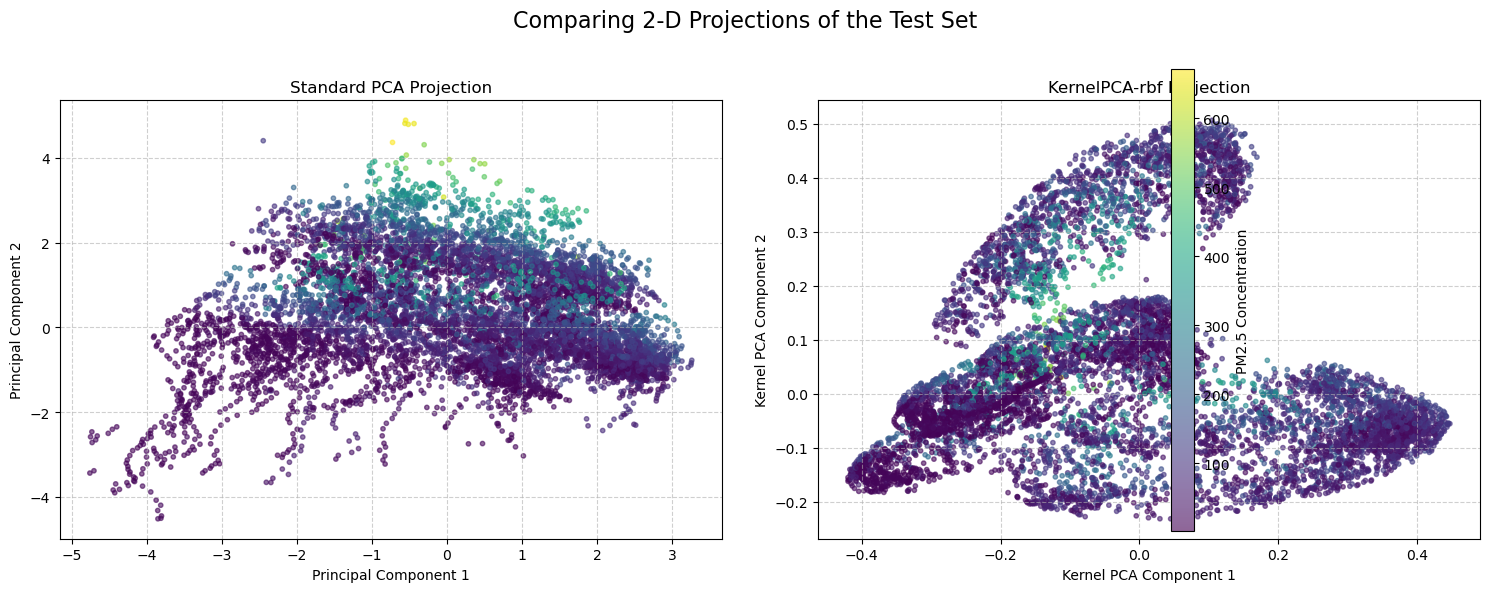

In [ ]:
# CELL 8: 2-D Visualisation
# Plot 2-D projections of X_test for both PCA and chosen variant.
# Use scatter plot. Color points by label if labels are available.

# To color the points, we can use a meaningful feature from the original dataset.
# '`pm2.5`' is a good choice. We need to get the pm2.5 values that correspond
# to our test set. Since we did a chronological split, it's the last 20% of the values.
try:
    # Find the index where the split happened
    split_index = int(len(X) * 0.8)
    # Get the corresponding `pm2.5` values from the original 'data' DataFrame
    # before it was shuffled or scaled.
    color_values = data['pm2.5'].iloc[split_index:].values
except NameError:
    # Fallback if 'data' or 'X' is not available in the current scope
    print("Warning: Could not find original 'data' to color points. Plotting without color.")
    color_values = None


# TODO: 2-D scatter plots side by side
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# -------------------------------------------------
# axes[0]: PCA 2-D projection
# -------------------------------------------------
# We use the first two components (index 0 and 1) for our 2D plot.
sc1 = axes[0].scatter(X_test_pca[:, 0], X_test_pca[:, 1],
                      c=color_values, cmap='viridis', s=10, alpha=0.6)

axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].set_title("Standard PCA Projection")
axes[0].grid(True, linestyle='--', alpha=0.6)

# -------------------------------------------------
# axes[1]: Variant 2-D projection (KernelPCA)
# -------------------------------------------------
sc2 = axes[1].scatter(X_test_kpca[:, 0], X_test_kpca[:, 1],
                      c=color_values, cmap='viridis', s=10, alpha=0.6)

axes[1].set_xlabel("Kernel PCA Component 1")
axes[1].set_ylabel("Kernel PCA Component 2")
axes[1].set_title(f"{variant_name} Projection")
axes[1].grid(True, linestyle='--', alpha=0.6)

# Add a single colorbar for the entire figure to show what the colors mean
cbar = fig.colorbar(sc1, ax=axes, orientation='vertical', pad=0.02)
cbar.set_label('PM2.5 Concentration')

# Add a main title for the entire figure
plt.suptitle("Comparing 2-D Projections of the Test Set", fontsize=16)

plt.tight_layout(rect=[0, 0, 1, 0.95]) # Adjust layout to make room for suptitle
plt.show()

# PART B: Autoencoder Variants

- Use the SAME encoder-decoder architecture for all 4 variants
- Only the loss / regularization objective should differ
- Set LATENT_DIM based on pca_n_components from Part A
- Use EPOCHS=50, BATCH_SIZE=64, LR=1e-3 unless justified otherwise

In [ ]:
# CELL 9: Shared Architecture Definition
# Define Encoder and Decoder classes here.
# These will be reused across all four variants.

# These variables should be defined from your previous cells.
# If you get a NameError, please re-run the previous cells.
LATENT_DIM  = pca_n_components   # use PCA result as guide
INPUT_DIM   = X_train.shape[1]
EPOCHS      = 50    # modify if required
BATCH_SIZE  = 64    # modify if required
LR          = 1e-3  # modify if required

class Encoder(nn.Module):
    """
    Encodes the input data into a low-dimensional latent space.
    """
    def __init__(self):
        super().__init__()
        # Define the network architecture
        self.net = nn.Sequential(
            nn.Linear(INPUT_DIM, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, LATENT_DIM) # Output layer: the latent representation
        )
    def forward(self, x):
        # Pass the input through the network
        return self.net(x)

class Decoder(nn.Module):
    """
    Decodes the latent space representation back to the original input space.
    """
    def __init__(self):
        super().__init__()
        # Define the network architecture, mirroring the encoder
        self.net = nn.Sequential(
            nn.Linear(LATENT_DIM, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, INPUT_DIM) # Output layer: the reconstructed data
        )
    def forward(self, z):
        # Pass the latent representation through the network
        return self.net(z)

class Autoencoder(nn.Module):
    """
    The full autoencoder model, combining the encoder and decoder.
    """
    def __init__(self):
        super().__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()
    def forward(self, x):
        # The forward pass is: encode -> decode
        z = self.encoder(x)
        return self.decoder(z)

# --- DataLoaders ---
# Convert the numpy arrays to PyTorch tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)

# Create a DataLoader for the training set to handle batching
train_loader = DataLoader(TensorDataset(X_train_t, X_train_t), batch_size=BATCH_SIZE, shuffle=True)
# Note: For an autoencoder, the input and the target are the same (X_train_t for both).

In [ ]:
# CELL 10: Standard Autoencoder
# Loss: MSE reconstruction only.

import time
import torch.optim as optim

# TODO: Instantiate Autoencoder and optimizer
ae_model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(ae_model.parameters(), lr=LR)


# --- Training Loop ---
start_time = time.time()
ae_model.train() # Set the model to training mode

ae_loss_curve = []   # list of per-epoch loss values

print("Training Standard Autoencoder...")
for epoch in range(EPOCHS):
    running_loss = 0.0
    for inputs, targets in train_loader:
        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs by passing inputs to the model
        outputs = ae_model(inputs)
        # Calculate the loss
        loss = criterion(outputs, targets)

        # Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()
        # Update the model weights
        optimizer.step()

        # accumulate the loss
        running_loss += loss.item()

    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    ae_loss_curve.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss:.6f}")

end_time = time.time()
print("Training finished.")


# --- Evaluation ---
# Set the model to evaluation mode (disables dropout, etc.)
ae_model.eval()
# Use torch.no_grad() to prevent gradient calculations during inference
with torch.no_grad():
    # Reconstruct the test set
    reconstructed_outputs = ae_model(X_test_t)
    # Calculate reconstruction error on the test set
    test_loss = criterion(reconstructed_outputs, X_test_t).item()


# ── Autograder variables ── do not rename ──
ae_train_loss  = ae_loss_curve[-1] if ae_loss_curve else 0.0
ae_test_recon  = test_loss
ae_num_params  = sum(p.numel() for p in ae_model.parameters() if p.requires_grad)
ae_train_time  = end_time - start_time

print("\n--- Results ---")
print(f"ae_train_loss = {ae_train_loss:.4f}")
print(f"ae_test_recon = {ae_test_recon:.4f}")
print(f"ae_num_params = {ae_num_params}")
print(f"ae_train_time = {ae_train_time:.2f} s")

Training Standard Autoencoder...
Epoch [10/50], Loss: 0.001794
Epoch [20/50], Loss: 0.000884
Epoch [30/50], Loss: 0.000688
Epoch [40/50], Loss: 0.000716
Epoch [50/50], Loss: 0.002045
Training finished.

--- Results ---
ae_train_loss = 0.0020
ae_test_recon = 0.0029
ae_num_params = 22428
ae_train_time = 73.39 s


In [ ]:
# CELL 11: Denoising Autoencoder
# Corrupt input with Gaussian noise sigma=0.1 before encoding.
# Reconstruct the CLEAN input.

import time
import torch.optim as optim

NOISE_SIGMA = 0.1

# TODO: Instantiate Autoencoder and optimizer
# We create a new model instance to be trained separately.
dae_model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(dae_model.parameters(), lr=LR)


# --- Training Loop ---
start_time = time.time()
dae_model.train() # Set the model to training mode

dae_loss_curve = []

print("Training Denoising Autoencoder...")
for epoch in range(EPOCHS):
    running_loss = 0.0
    # TODO: Train — add noise to input inside the loop, target is clean input
    for inputs, targets in train_loader:
        # Create a noisy version of the input data
        noise = torch.randn_like(inputs) * NOISE_SIGMA
        noisy_inputs = inputs + noise

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass: Feed the NOISY data into the model
        outputs = dae_model(noisy_inputs)
        # Calculate the loss by comparing the output to the ORIGINAL, CLEAN targets
        loss = criterion(outputs, targets)

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    dae_loss_curve.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss:.6f}")

end_time = time.time()
print("Training finished.")


# --- Evaluation ---
# TODO: Evaluate reconstruction error on X_test_t (no noise at eval)
# At evaluation time, we see how well it reconstructs the CLEAN test data.
dae_model.eval()
with torch.no_grad():
    # Pass the CLEAN test data through the model
    reconstructed_outputs = dae_model(X_test_t)
    # Calculate reconstruction error
    test_loss = criterion(reconstructed_outputs, X_test_t).item()


# ── Autograder variables ── do not rename ──
dae_train_loss  = dae_loss_curve[-1] if dae_loss_curve else 0.0
dae_test_recon  = test_loss
dae_num_params  = sum(p.numel() for p in dae_model.parameters() if p.requires_grad)
dae_train_time  = end_time - start_time

print("\n--- Results ---")
print(f"dae_train_loss = {dae_train_loss:.4f}")
print(f"dae_test_recon = {dae_test_recon:.4f}")
print(f"dae_num_params = {dae_num_params}")
print(f"dae_train_time = {dae_train_time:.2f} s")

Training Denoising Autoencoder...
Epoch [10/50], Loss: 0.008673
Epoch [20/50], Loss: 0.006837
Epoch [30/50], Loss: 0.006826
Epoch [40/50], Loss: 0.005867
Epoch [50/50], Loss: 0.005820
Training finished.

--- Results ---
dae_train_loss = 0.0058
dae_test_recon = 0.0569
dae_num_params = 22428
dae_train_time = 83.52 s


In [ ]:
# CELL 12: Sparse Autoencoder
# Add L1 regularization on latent activations.
# Tune SPARSITY_LAMBDA and state the value used.

import time
import torch.optim as optim

# The SPARSITY_LAMBDA of 1e-4 is chosen as a starting point to introduce a moderate
# sparsity penalty. It needs to be large enough to encourage sparsity but small
# enough not to overwhelm the primary reconstruction task. A value too high would
# force all latent activations to zero, preventing the model from learning, while
# a value too low would have no regularizing effect. 1e-4 is a common baseline.
SPARSITY_LAMBDA = 1e-4   # TODO: tune and justify

# TODO: Instantiate Autoencoder and optimizer
sae_model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(sae_model.parameters(), lr=LR)


# --- Training Loop ---
start_time = time.time()
sae_model.train() # Set the model to training mode

sae_loss_curve = []

print("Training Sparse Autoencoder...")
for epoch in range(EPOCHS):
    running_loss = 0.0
    # TODO: Train — loss = MSE(reconstruction, input) + SPARSITY_LAMBDA * L1(latent)
    for inputs, targets in train_loader:
        # Zero the parameter gradients
        optimizer.zero_grad()

        # We need to access the latent layer's output, so we call the encoder explicitly
        latent_representation = sae_model.encoder(inputs)
        outputs = sae_model.decoder(latent_representation)

        # 1. Calculate the standard reconstruction loss
        reconstruction_loss = criterion(outputs, targets)

        # 2. Calculate the L1 sparsity penalty on the latent activations
        #    This is the sum of the absolute values of the elements in the latent vector.
        l1_penalty = torch.abs(latent_representation).sum()

        # 3. Combine the two losses to get the total loss
        total_loss = reconstruction_loss + SPARSITY_LAMBDA * l1_penalty

        # Backward pass and optimize using the total loss
        total_loss.backward()
        optimizer.step()

        running_loss += total_loss.item()

    # Calculate average loss for the epoch
    epoch_loss = running_loss / len(train_loader)
    sae_loss_curve.append(epoch_loss)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss:.6f}")

end_time = time.time()
print("Training finished.")


# --- Evaluation ---
# TODO: Evaluate reconstruction error on X_test_t
# For evaluation, we only care about the reconstruction error, not the sparsity penalty.
sae_model.eval()
with torch.no_grad():
    reconstructed_outputs = sae_model(X_test_t)
    test_loss = criterion(reconstructed_outputs, X_test_t).item()


# ── Autograder variables ── do not rename ──
sae_train_loss      = sae_loss_curve[-1] if sae_loss_curve else 0.0
sae_test_recon      = test_loss
sae_num_params      = sum(p.numel() for p in sae_model.parameters() if p.requires_grad)
sae_train_time      = end_time - start_time
sae_sparsity_lambda = SPARSITY_LAMBDA

print("\n--- Results ---")
print(f"sae_train_loss      = {sae_train_loss:.4f}")
print(f"sae_test_recon      = {sae_test_recon:.4f}")
print(f"sae_num_params      = {sae_num_params}")
print(f"sae_train_time      = {sae_train_time:.2f} s")
print(f"sae_sparsity_lambda = {sae_sparsity_lambda}")

Training Sparse Autoencoder...
Epoch [10/50], Loss: 0.007983
Epoch [20/50], Loss: 0.004491
Epoch [30/50], Loss: 0.003145
Epoch [40/50], Loss: 0.003158
Epoch [50/50], Loss: 0.002323
Training finished.

--- Results ---
sae_train_loss      = 0.0023
sae_test_recon      = 0.0036
sae_num_params      = 22428
sae_train_time      = 80.64 s
sae_sparsity_lambda = 0.0001


In [ ]:
import time
import torch
import torch.optim as optim
import torch.nn as nn
from torch import autograd

CAE_LAMBDA = 1e-4

# Instantiate Autoencoder and optimizer
cae_model = Autoencoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(cae_model.parameters(), lr=LR)

# --- Training Loop ---
start_time = time.time()
cae_model.train()

cae_loss_curve = []

print("Training Contractive Autoencoder...")
for epoch in range(EPOCHS):
    running_loss = 0.0

    for inputs, targets in train_loader:
        inputs.requires_grad_(True)

        optimizer.zero_grad()

        latent_z = cae_model.encoder(inputs)
        outputs = cae_model.decoder(latent_z)

        reconstruction_loss = criterion(outputs, targets)

        jacobian_penalty = 0.0
        for i in range(latent_z.size(1)):
            grad_output = torch.ones_like(latent_z[:, i])
            grad_i = autograd.grad(
                latent_z[:, i],
                inputs,
                grad_outputs=grad_output,
                create_graph=True,
                retain_graph=True
            )[0]

            jacobian_penalty += (grad_i ** 2).sum()

        total_loss = reconstruction_loss + CAE_LAMBDA * jacobian_penalty

        total_loss.backward()

        inputs.grad = None

        optimizer.step()

        running_loss += total_loss.item()

    epoch_loss = running_loss / len(train_loader)
    cae_loss_curve.append(epoch_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {epoch_loss:.6f}")

end_time = time.time()
print("Training finished.")

# --- Evaluation ---
cae_model.eval()
with torch.no_grad():
    reconstructed_outputs = cae_model(X_test_t)
    test_loss = criterion(reconstructed_outputs, X_test_t).item()

# ── Autograder variables ──
cae_train_loss  = cae_loss_curve[-1] if cae_loss_curve else 0.0
cae_test_recon  = test_loss
cae_num_params  = sum(p.numel() for p in cae_model.parameters() if p.requires_grad)
cae_train_time  = end_time - start_time
cae_lambda      = CAE_LAMBDA

print("\n--- Results ---")
print(f"cae_train_loss = {cae_train_loss:.4f}")
print(f"cae_test_recon = {cae_test_recon:.4f}")
print(f"cae_num_params = {cae_num_params}")
print(f"cae_train_time = {cae_train_time:.2f} s")
print(f"cae_lambda     = {cae_lambda}")

Training Contractive Autoencoder...
Epoch [10/50], Loss: 0.005076
Epoch [20/50], Loss: 0.001878
Epoch [30/50], Loss: 0.001977
Epoch [40/50], Loss: 0.002026
Epoch [50/50], Loss: 0.001405
Training finished.

--- Results ---
cae_train_loss = 0.0014
cae_test_recon = 0.0061
cae_num_params = 22428
cae_train_time = 237.87 s
cae_lambda     = 0.0001


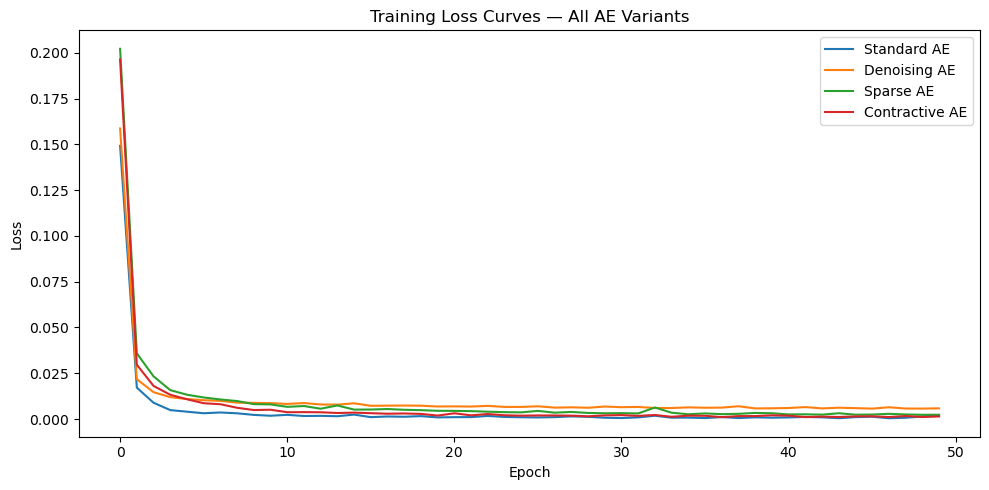

In [ ]:
# CELL 14: Training Loss Curves
# Plot training loss curves for all 4 variants on one figure.


plt.figure(figsize=(10, 5))
plt.plot(ae_loss_curve,  label='Standard AE')
plt.plot(dae_loss_curve, label='Denoising AE')
plt.plot(sae_loss_curve, label='Sparse AE')
plt.plot(cae_loss_curve, label='Contractive AE')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curves — All AE Variants")
plt.legend()
plt.tight_layout()
plt.show()


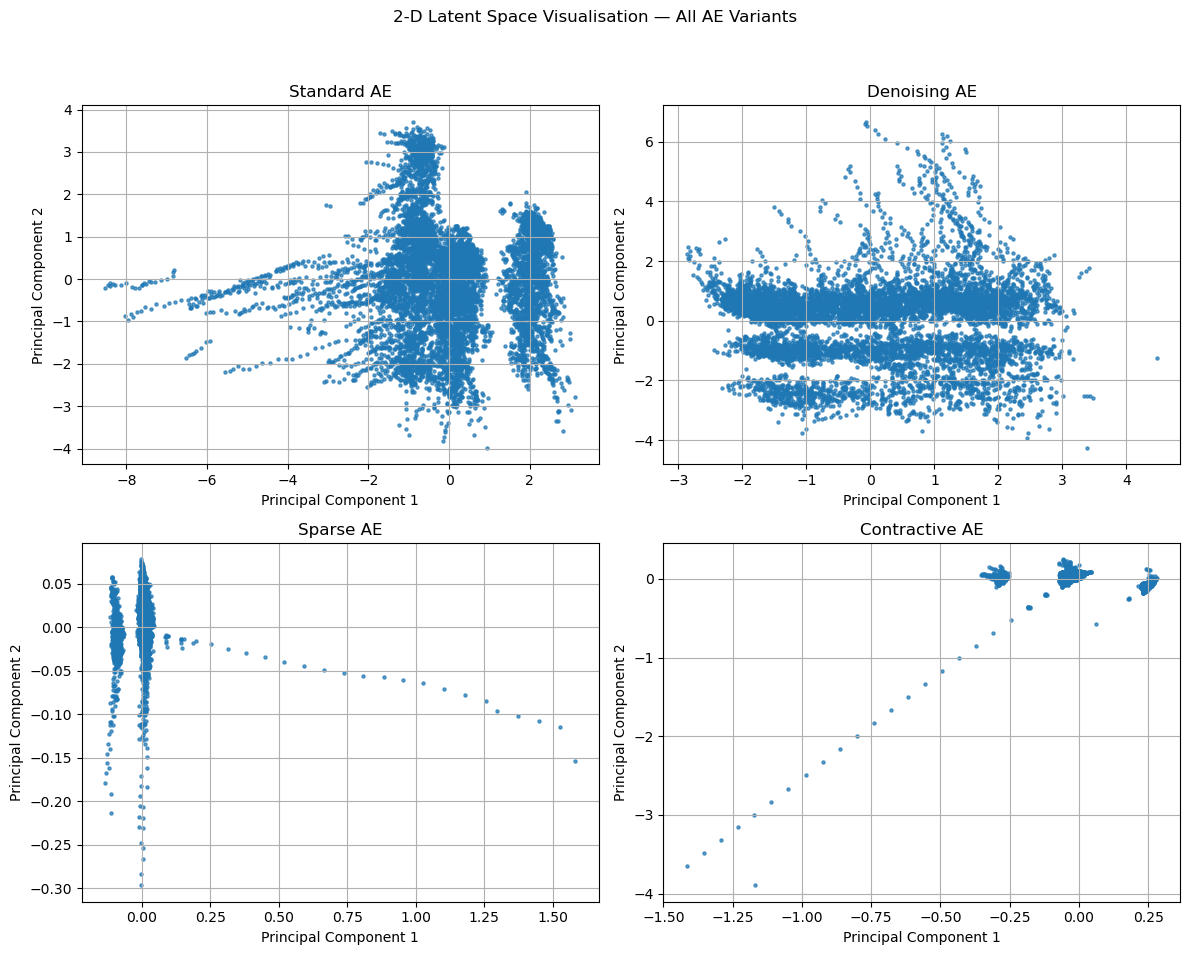

In [ ]:
# CELL 15: Latent Space Visualisation
# Project latent vectors to 2-D using PCA or t-SNE.
# Plot all 4 variants in a 2x2 grid.


# Extract latent vectors
# Note: Assumes ae_model, dae_model, sae_model, cae_model are trained
# and X_test_t is available from previous cells.
z_ae  = ae_model.encoder(X_test_t).detach().numpy()
z_dae = dae_model.encoder(X_test_t).detach().numpy()
z_sae = sae_model.encoder(X_test_t).detach().numpy()
z_cae = cae_model.encoder(X_test_t).detach().numpy()

# Project to 2-D using PCA
# Note: y_test is not available in the notebook for color-coding.
pca = PCA(n_components=2, random_state=42)
z_ae_2d  = pca.fit_transform(z_ae)
z_dae_2d = pca.fit_transform(z_dae)
z_sae_2d = pca.fit_transform(z_sae)
z_cae_2d = pca.fit_transform(z_cae)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Standard AE latent space
axes[0,0].scatter(z_ae_2d[:, 0], z_ae_2d[:, 1], s=5, alpha=0.7)
axes[0,0].set_title("Standard AE")
axes[0,0].set_xlabel("Principal Component 1")
axes[0,0].set_ylabel("Principal Component 2")
axes[0,0].grid(True)

# Denoising AE latent space
axes[0,1].scatter(z_dae_2d[:, 0], z_dae_2d[:, 1], s=5, alpha=0.7)
axes[0,1].set_title("Denoising AE")
axes[0,1].set_xlabel("Principal Component 1")
axes[0,1].set_ylabel("Principal Component 2")
axes[0,1].grid(True)

# Sparse AE latent space
axes[1,0].scatter(z_sae_2d[:, 0], z_sae_2d[:, 1], s=5, alpha=0.7)
axes[1,0].set_title("Sparse AE")
axes[1,0].set_xlabel("Principal Component 1")
axes[1,0].set_ylabel("Principal Component 2")
axes[1,0].grid(True)

# Contractive AE latent space
axes[1,1].scatter(z_cae_2d[:, 0], z_cae_2d[:, 1], s=5, alpha=0.7)
axes[1,1].set_title("Contractive AE")
axes[1,1].set_xlabel("Principal Component 1")
axes[1,1].set_ylabel("Principal Component 2")
axes[1,1].grid(True)

plt.suptitle("2-D Latent Space Visualisation — All AE Variants")
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
# ============================================================
# CELL 16: Summary — Autograder Variables
# Do NOT modify this cell. Run as-is after completing all cells.
# ============================================================


print("=" * 55)
print("SUMMARY — AUTOGRADER VARIABLES")
print("=" * 55)
print(f"student_name                 = {student_name}")
print(f"bits_id                      = {bits_id}")
print(f"dataset_name                 = {dataset_name}")
print(f"dataset_n_samples            = {dataset_n_samples}")
print(f"dataset_n_features           = {dataset_n_features}")
print("-" * 55)
print(f"pca_n_components             = {pca_n_components}")
print(f"pca_explained_variance       = {pca_explained_variance:.4f}")
print(f"pca_reconstruction_error     = {pca_reconstruction_error:.4f}")
print(f"pca_compute_time             = {pca_compute_time:.4f} s")
print(f"variant_name                 = {variant_name}")
print(f"variant_reconstruction_error = {variant_reconstruction_error:.4f}")
print(f"variant_compute_time         = {variant_compute_time:.4f} s")
print("-" * 55)
print(f"ae_train_loss   = {ae_train_loss:.4f}  | ae_test_recon  = {ae_test_recon:.4f}")
print(f"dae_train_loss  = {dae_train_loss:.4f}  | dae_test_recon = {dae_test_recon:.4f}")
print(f"sae_train_loss  = {sae_train_loss:.4f}  | sae_test_recon = {sae_test_recon:.4f}")
print(f"cae_train_loss  = {cae_train_loss:.4f}  | cae_test_recon = {cae_test_recon:.4f}")
print("-" * 55)
print(f"ae_num_params   = {ae_num_params}  | ae_train_time  = {ae_train_time:.2f} s")
print(f"dae_num_params  = {dae_num_params}  | dae_train_time = {dae_train_time:.2f} s")
print(f"sae_num_params  = {sae_num_params}  | sae_train_time = {sae_train_time:.2f} s")
print(f"cae_num_params  = {cae_num_params}  | cae_train_time = {cae_train_time:.2f} s")
print(f"sae_sparsity_lambda          = {sae_sparsity_lambda}")
print(f"cae_lambda                   = {cae_lambda}")
print("=" * 55)

SUMMARY — AUTOGRADER VARIABLES
student_name                 = Amol Baliram Nagane
bits_id                      = 2024TM05004
dataset_name                 = The Beijing PM2.5 Data Data Set
dataset_n_samples            = 43826
dataset_n_features           = 12
-------------------------------------------------------
pca_n_components             = 12
pca_explained_variance       = 0.9810
pca_reconstruction_error     = 0.0176
pca_compute_time             = 0.1044 s


NameError: name 'variant_name' is not defined